<h1 style="color:green;font-size:22px;">Function 1 - Black-Box Optimisation</h1>
<h1 style="color:#0000CD;font-size:19px;"">Introduction and illustrative analogy</h1>

**Function 1** is a two-dimensional black-box objective over the bounded domain $[0,1]^2$. Its analytical form and physical interpretation are unknown. The objective is to identify high-value input configurations under a limited sequential-query budget.

As an illustrative analogy, imagine searching a two-dimensional area for small hidden contamination sources with a detector, where readings may change only near a source. Bayesian optimisation uses each observation to decide where to search next, balancing unexplored areas with promising locations.

The goal is to maximise **Function 1**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Rectangle


from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

<h1 style="color:#0000CD;font-size:19px;"">Week 1</h1>

**1.1 - Extraction of Initial Data**

In [2]:
inputs = np.load('Initial Data/function_1/initial_inputs.npy')
outputs = np.load('Initial Data/function_1/initial_outputs.npy')
print(inputs.shape, outputs.shape)

(10, 2) (10,)


In [3]:
data = pd.DataFrame(inputs, columns=['x1','x2'])
data['y'] = outputs
display(data)

,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**1.2 - Geometric exploration of intuitive candidates**

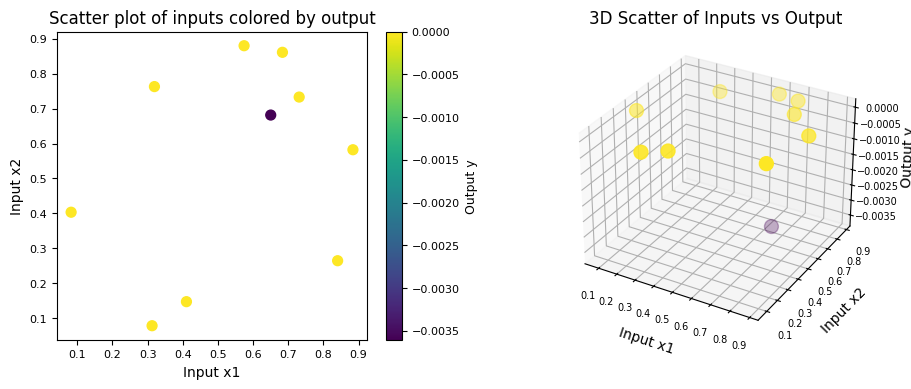

In [4]:
# Create figure with 2 subplots side by side
fig = plt.figure(figsize=(11,4))

# 2D-Data Exploration
ax1 = fig.add_subplot(1, 2, 1)
sc = ax1.scatter(data['x1'], data['x2'], c=data['y'], cmap='viridis', s=50)

cbar1 = plt.colorbar(sc, ax=ax1)
cbar1.set_label('Output y', fontsize=9)
cbar1.ax.tick_params(labelsize=8) 

ax1.tick_params(axis='both', labelsize=8)
ax1.set_xlabel('Input x1')
ax1.set_ylabel('Input x2')
ax1.set_title('Scatter plot of inputs colored by output')

# 3D-Data Exploration
ax2 = fig.add_subplot(1,2,2, projection='3d')
ax2.scatter(data['x1'], data['x2'], data['y'], c=data['y'], cmap='viridis', s=100)
ax2.tick_params(axis='both', labelsize=7)
ax2.set_xlabel('Input x1')
ax2.set_ylabel('Input x2')
ax2.set_zlabel('Output y')
ax2.set_title('3D Scatter of Inputs vs Output')

plt.show()

**Observations:**
- \$ (x_1, x_2) \in [0, 1]^2\$
- One initial observation point (0.650114, 0.681526) has its output (-3.606063e-03)  significantly lower than the other points. Otherwise other remaining points have magnitudes close to zero.
- The observed maximum (0.731024, 0.733000) is also practically ~0 (7.7e-16).

**Interpretation:**
- Most of the initially sampled locations returned responses numerically close to zero. However, the limited initial design does not establish whether the unsampled domain is globally flat or contains narrow localised features.
- There is no obvious strong positive peak yet.
- The sparse initial design does not establish that the unsampled domain is flat or that the substantially negative observation belongs to an extended valley.
- Early rounds therefore prioritise exploration of poorly sampled locations rather than local exploitation of the incumbent.

**Geometric Exploration:**
- A small set of intuitive candidate locations is first considered: the four corners (0,0), (0,1), (1,1), (1,0) and the centre of the domain (0.5,0.5). These points are compared using their distances from the nearest existing observations. This provides a simple, interpretable exploration benchmark before extending the same distance-based principle to a full candidate grid. Among the intuitive candidates, (0,0) is furthest from the substantially negative observation (0.650114, 0.681526). However, under the maximin nearest-neighbour criterion, (0,1) is the least-covered candidate and is therefore preferred for geometric exploration.

In [5]:
def distanceClosestPoint(x,y,n):
    p = np.array([x, y])
    d = np.array([np.linalg.norm(p - np.array([u,v])) for (u,v) in inputs ])
    r = np.sort(d)[:n]
    return float(r.sum())

query_points = [(0,0), (0,1), (1,0), (1,1), (0.5,0.5)]
nb_points = [1,3,5]

for n in nb_points:
    print("Distances From ",n, "closest point(s):")
    for x,y in query_points:
        print((x,y),":",distanceClosestPoint(x,y,n))
    print('\n')

Distances From  1 closest point(s):
(0, 0) : 0.3224485002380642
(0, 1) : 0.39775256435676853
(1, 0) : 0.30914375125905713
(1, 1) : 0.34572978467882404
(0.5, 0.5) : 0.2355547652703174


Distances From  3 closest point(s):
(0, 0) : 1.1704400694534556
(0, 1) : 1.58669657672784
(1, 0) : 1.5106091039867398
(1, 1) : 1.1583069308187186
(0.5, 0.5) : 0.8826743985358633


Distances From  5 closest point(s):
(0, 0) : 2.878624733460741
(0, 1) : 3.0080250027399114
(1, 0) : 2.9685045257995712
(1, 1) : 2.073719799745944
(0.5, 0.5) : 1.633423145006783




Using the maximum distance to closest points, Geometric Exploration suggests to query next (0,1).

**1.3 - Grid-based distance exploration**

In [6]:
# Candidate points (grid)
x1 = np.linspace(0,1,50)
x2 = np.linspace(0,1,50)
xx1, xx2 = np.meshgrid(x1, x2)
X_grid = np.vstack([xx1.ravel(), xx2.ravel()]).T

# Compute min distance from each candidate to existing points
distances = np.min(np.linalg.norm(X_grid[:,None,:] - inputs[None,:,:], axis=2), axis=1)

# Select candidate with largest min distance (furthest from existing points)
next_idx = np.argmax(distances)
next_point = X_grid[next_idx]
print(f"Next point (furthest from existing points):{next_point[0]:.3f}-{next_point[1]:.3f}")

Next point (furthest from existing points):0.000-1.000


**1.4 - Bayesian Optimisation using Gaussian Process + Upper Confidence Bound**

**Numerical Scale Consideration:** The observed outputs span an exceptionally wide numerical range. The negative observation therefore dominates the variance of the raw target, while the extremely small positive observations may be difficult for the global Gaussian Process to distinguish. The initial GP should consequently be interpreted primarily as a broad exploration model rather than as a precise ranking of near-zero observations.

In [7]:
kernel = RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)

# Upper Confidence Bound
kappa = 1.5
ucb = y_pred + kappa * sigma
index_max = np.argmax(ucb)
next_point = np.array(X_grid[index_max], float)
print(f"Next point (with GP +UCB):{next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP +UCB):0.877551-1.000000


Given the data,  the observed responses are generally close to 0 except 1 point, we focus on exploration rather than exploitation. 

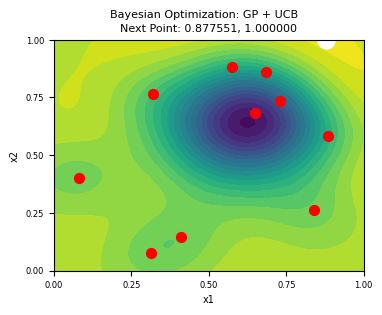

In [8]:
fig, ax = plt.subplots(1, 1,figsize=(4,3)) 

contour = ax.contourf(xx1, xx2, ucb.reshape(50,50), levels=20, cmap='viridis')
ax.scatter(inputs[:,0], inputs[:,1], c='red', s=50, label='Observed')
ax.scatter(next_point[0], next_point[1], c='white', s=150, label='Next')

ax.set_title(f'Next Point: {next_point[0]:.6f}, {next_point[1]:.6f}', fontsize=8)
ax.set_xticks(np.linspace(0,1,5))
ax.set_yticks(np.linspace(0,1,5))
ax.set_xlabel("x1", fontsize=7)
ax.set_ylabel("x2", fontsize=7)
ax.tick_params(axis='both', labelsize=6)

fig.suptitle('Bayesian Optimization: GP + UCB', fontsize=8)

plt.show()

**1.5 - Comparison of Geometric vs GP-UCB candidates**

In [9]:
#Acquisition Comparison (UCB) forGeometric Vs Bayesian Optimisation 
point = np.array([0, 1])
idx = np.where(np.all(np.isclose(X_grid, point), axis=1))[0][0]
print(f"UCB at geometric candidate [0, 1]: {ucb[idx]:.6f}")
print(f"Maximum UCB over the grid: {ucb[index_max]:.6f}")

UCB at geometric candidate [0, 1]: 0.001959
Maximum UCB over the grid: 0.002101


**1.6 - Observed Range Diagnostics**

In [10]:
best = outputs.max()
field = outputs.max() - outputs.min()
print(best, field)

7.710875114502849e-16 0.0036060626443642474


In GP + UCB Framework, the acquisition function suggest a more interesting point to explore as (0.877551,1.000000)

<h1 style="color:#0000CD;font-size:19px;"">Week 2</h1>

**2.1 - Previous Week's Query Result**

In [11]:
# New Query Point
x_new = np.array([0.877551, 1.000000])
y_new = 1.2259935799032287e-139

def add_QueriedPoint(data, x_new, y_new):

    inputs = data[['x1', 'x2']].to_numpy()
    outputs = data['y'].to_numpy()
    
    # Checks if New Points is already included in data
    exists = False
    for i in range(inputs.shape[0]):
        if np.allclose(inputs[i], x_new) and np.isclose(outputs[i], y_new):
            exists = True
            break

    # Only adds if it doesn't exist already 
    if not exists:
        inputs = np.vstack([inputs, x_new])
        outputs = np.append(outputs, y_new)
        data = pd.DataFrame(inputs, columns=['x1', 'x2']).assign(y=outputs)
    
        print("Point added!")
    else:
        print("Point already exists, skipping addition.")
    return data

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**2.2 - Next Point Query**

In [12]:
kernel = RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)

gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)

# Upper Confidence Bound
kappa = 1.5
ucb = y_pred + kappa * sigma
index_max = np.argmax(ucb)
next_point = np.array(X_grid[index_max], float)
print(f"Next point (with GP +UCB):{next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP +UCB):0.326531-1.000000


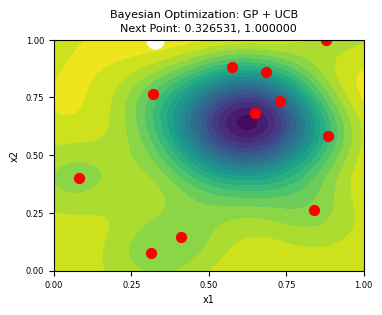

In [13]:
fig, ax = plt.subplots(1, 1,figsize=(4,3)) 

contour = ax.contourf(xx1, xx2, ucb.reshape(50,50), levels=20, cmap='viridis')
ax.scatter(inputs[:,0], inputs[:,1], c='red', s=50, label='Observed')
ax.scatter(next_point[0], next_point[1], c='white', s=150, label='Next')

ax.set_title(f'Next Point: {next_point[0]:.6f}, {next_point[1]:.6f}', fontsize=8)
ax.set_xticks(np.linspace(0,1,5))
ax.set_yticks(np.linspace(0,1,5))
ax.set_xlabel("x1", fontsize=7)
ax.set_ylabel("x2", fontsize=7)
ax.tick_params(axis='both', labelsize=6)

fig.suptitle('Bayesian Optimization: GP + UCB', fontsize=8)

plt.show()

**2.3 - Diagnostics**

In [14]:
best = outputs.max()
field = outputs.max() - outputs.min()
print(best, field)

7.710875114502849e-16 0.0036060626443642474


<h1 style="color:#0000CD;font-size:19px;"">Week 3</h1>

**3.1 - Previous Week's Query Result**

In [15]:
# New Query Point
x_new = np.array([0.326531, 1.000000])
y_new = -6.43315543369651e-160

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**3.2 - Next Point Query**

The first two UCB queries did not improve the incumbent. The exploration parameter $\kappa$ is therefore increased from 1.5 to 2.0, placing slightly more weight on posterior uncertainty while maintaining a global search strategy.

In [16]:
kernel = RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)

# Upper Confidence Bound
kappa = 2
ucb = y_pred + kappa * sigma
index_max = np.argmax(ucb)
next_point = np.array(X_grid[index_max], float)
print(f"Next point (with GP + UCB):{next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP + UCB):0.020408-0.775510


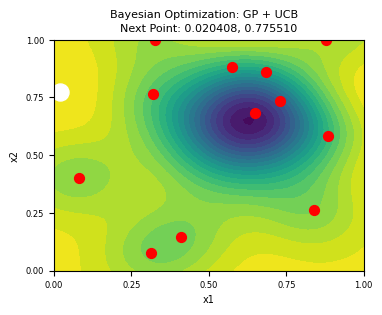

In [17]:
fig, ax = plt.subplots(1, 1,figsize=(4,3)) 

contour = ax.contourf(xx1, xx2, ucb.reshape(50,50), levels=20, cmap='viridis')
ax.scatter(inputs[:,0], inputs[:,1], c='red', s=50, label='Observed')
ax.scatter(next_point[0], next_point[1], c='white', s=150, label='Next')

ax.set_title(f'Next Point: {next_point[0]:.6f}, {next_point[1]:.6f}', fontsize=8)
ax.set_xticks(np.linspace(0,1,5))
ax.set_yticks(np.linspace(0,1,5))
ax.set_xlabel("x1", fontsize=7)
ax.set_ylabel("x2", fontsize=7)
ax.tick_params(axis='both', labelsize=6)

fig.suptitle('Bayesian Optimization: GP + UCB', fontsize=8)

plt.show()

**3.3 - Diagnostics**

In [18]:
best = outputs.max()
field = outputs.max() - outputs.min()
print(best, field)

7.710875114502849e-16 0.0036060626443642474


<h1 style="color:#0000CD;font-size:19px;"">Week 4</h1>

**4.1 - Previous Week's Query Result**

In [19]:
# New Query Point
x_new = np.array([0.020408, 0.775510])
y_new = 3.1776222232122792e-201

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


The first three sequential queries also returned values numerically close to zero. This provides no evidence of a broad positive region, but it does not rule out narrow local structure. For one further exploration-oriented UCB query, κ is increased from 2.0 to 2.25.

**4.2 - Next Point Query**

In [20]:
kernel = RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)

# Upper Confidence Bound
kappa = 2.25
ucb = y_pred + kappa * sigma
index_max = np.argmax(ucb)
next_point = np.array(X_grid[index_max], float)
print(f"Next point (with GP +UCB):{next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP +UCB):0.693878-0.000000


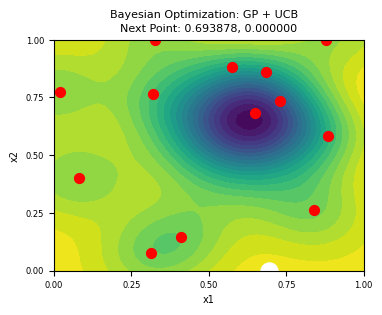

In [21]:
fig, ax = plt.subplots(1, 1,figsize=(4,3)) 

contour = ax.contourf(xx1, xx2, ucb.reshape(50,50), levels=20, cmap='viridis')
ax.scatter(inputs[:,0], inputs[:,1], c='red', s=50, label='Observed')
ax.scatter(next_point[0], next_point[1], c='white', s=150, label='Next')

ax.set_title(f'Next Point: {next_point[0]:.6f}, {next_point[1]:.6f}', fontsize=8)
ax.set_xticks(np.linspace(0,1,5))
ax.set_yticks(np.linspace(0,1,5))
ax.set_xlabel("x1", fontsize=7)
ax.set_ylabel("x2", fontsize=7)
ax.tick_params(axis='both', labelsize=6)

fig.suptitle('Bayesian Optimization: GP + UCB', fontsize=8)

plt.show()

<h1 style="color:#0000CD;font-size:19px;"">Week 5</h1>

**5.1 - Previous Week's Query Result**

In [22]:
# New Query Point
x_new = np.array([0.693878, 0.000000])
y_new = 4.060743331513648e-177

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**5.2 - Diagnostics following results**
 
- None of the first four sequential queries improved the initial incumbent. Most observed responses remain numerically close to zero, while one interior observation is substantially negative.
- This creates a boundary bias: UCB explores where uncertainty is highest (at the boundaries because mean is ~0 and flat).
- Let's shift the optimisation problem from exploring the domain to find the best region using EI: we reduce the emphasis on uncertainty-driven exploration by replacing UCB with Expected Improvement. At the same time, the RBF length scale is allowed to adapt to the observed data rather than remaining fixed at 0.2.

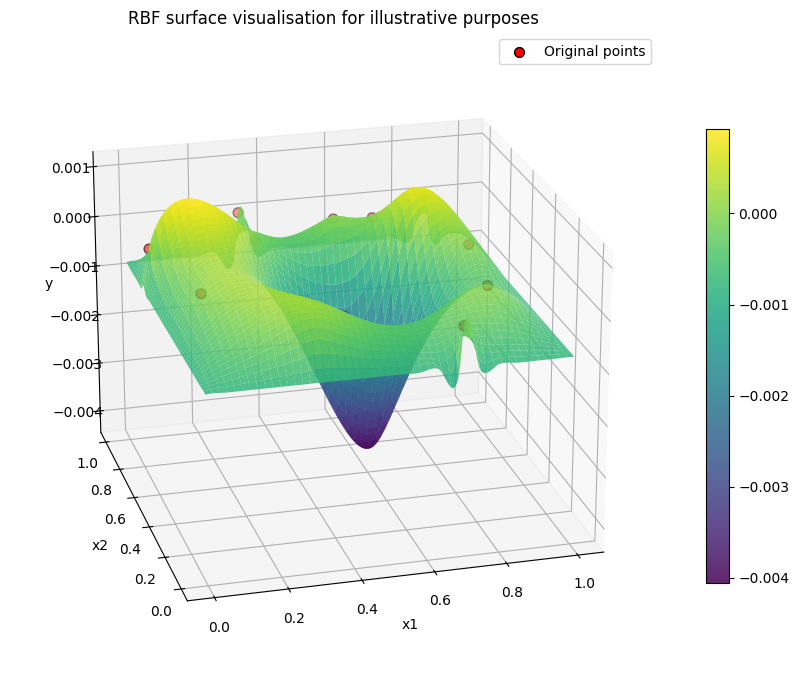

In [23]:
from scipy.interpolate import Rbf
#from scipy.linalg import LinAlgWarning

#warnings.filterwarnings("ignore", category=LinAlgWarning)

x1 = data['x1']
x2 = data['x2']
y = data['y']

# Add synthetic boundary hugging points
n_edge = 20
t = np.linspace(0, 1, n_edge)

# four edges of the unit square
xb = np.concatenate([t, t, np.zeros_like(t), np.ones_like(t)])
yb = np.concatenate([np.zeros_like(t), np.ones_like(t), t, t])

# Add synthetic negative boundary values to visually constrain the RBF surface.
# This reduces edge extrapolation and improves the contrast of promising interior regions. 
# These points are illustrative only and are not used in the optimisation model.
boundary_points = np.unique(np.column_stack([xb, yb]),axis=0)
xb = boundary_points[:, 0]
yb = boundary_points[:, 1]
y_boundary = np.full(len(boundary_points), -8e-4)

# combine original + boundary points
x1_aug = np.concatenate([x1, xb])
x2_aug = np.concatenate([x2, yb])
y_aug  = np.concatenate([y, y_boundary])

# exact interpolation on augmented dataset
rbf = Rbf(x1_aug, x2_aug, y_aug, function='thin_plate', smooth=0)

# grid
grid_n = 500
xg = np.linspace(0, 1, grid_n)
yg = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(xg, yg)
Z = rbf(X1, X2)

# plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.85, linewidth=0)
ax.scatter(x1, x2, y, c='red', s=50, edgecolor='k', label='Original points')
#ax.scatter(xb, yb, y_boundary, c='orange', s=25, label='Boundary control points')

ax.set_title("RBF surface visualisation for illustrative purposes")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")
ax.legend()

ax.view_init(elev=22, azim=255)
fig.colorbar(surf, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()


**Exploratory RBF Visualisation:** To support qualitative interpretation of the sparse observations, an RBF interpolator is fitted using the observed points together with artificial boundary anchors assigned a value of (-8\times10^{-4}). These boundary anchors are introduced solely to regularise the visualisation and prevent unconstrained behaviour near the edges of the domain.

Under this specific boundary assumption, the interpolated surface displays two comparatively elevated areas: [0.05,0.30]x[0.70,0.95] and [0.70,0.95]x[0.70,0.95]. These are qualitative hypothesis regions whose shape depends on the boundary assumptions. They do not determine candidate selection, which remains driven by the GP acquisition function fitted to observed data.

**5.3 - Next point query (Switch to EI)**

In [24]:
# Increase the resolution of Candidate points to 500x500 (grid)
x1 = np.linspace(0,1,500)
x2 = np.linspace(0,1,500)
xx1, xx2 = np.meshgrid(x1, x2)
X_grid = np.vstack([xx1.ravel(), xx2.ravel()]).T

kernel = RBF(length_scale=0.2, length_scale_bounds=(0.05,1.0))+ WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)

# Best observed value so far
f_best = np.max(outputs)

# Expected Improvement
improvement = y_pred - f_best

# Z value
z = improvement / sigma

# Expected Improvement
ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)

# Next point
index_max = np.argmax(ei)
next_point = X_grid[index_max]
print(f"Next point (with GP + EI): {next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP + EI): 0.765531-0.763527


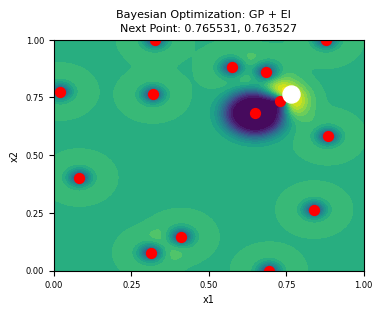

In [25]:
fig, ax = plt.subplots(1, 1,figsize=(4,3)) 

contour = ax.contourf(xx1, xx2, ei.reshape(500,500), levels=20, cmap='viridis')
ax.scatter(inputs[:,0], inputs[:,1], c='red', s=50, label='Observed')
ax.scatter(next_point[0], next_point[1], c='white', s=150, label='Next')

ax.set_title(f'Next Point: {next_point[0]:.6f}, {next_point[1]:.6f}', fontsize=8)
ax.set_xticks(np.linspace(0,1,5))
ax.set_yticks(np.linspace(0,1,5))
ax.set_xlabel("x1", fontsize=7)
ax.set_ylabel("x2", fontsize=7)
ax.tick_params(axis='both', labelsize=6)

fig.suptitle('Bayesian Optimization: GP + EI', fontsize=8)

plt.show()

<h1 style="color:#0000CD;font-size:19px;"">Week 6</h1>

**6.1 - Previous Week's Query Result**

In [26]:
# Queried Point result
x_new = np.array([0.765531, 0.763527])
y_new = 1.749055452140406e-26

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**6.2 - Next point query (EI)**

In [27]:
kernel = RBF(length_scale=0.2, length_scale_bounds=(0.05,1.0))+ WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)

# Best observed value so far
f_best = np.max(outputs)

# Expected Improvement
improvement = y_pred - f_best

# Z value
Z = improvement / sigma

# Expected Improvement
ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)

# Next point
index_max = np.argmax(ei)
next_point = X_grid[index_max]
print(f"Next point (with GP + EI): {next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP + EI): 0.783567-0.699399


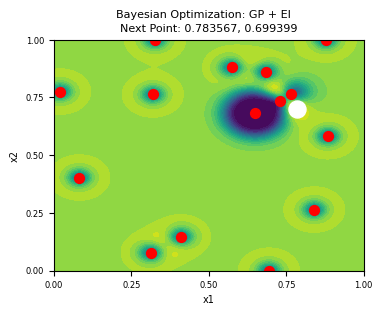

In [28]:
fig, ax = plt.subplots(1, 1,figsize=(4,3)) 

contour = ax.contourf(xx1, xx2, ei.reshape(500,500), levels=20, cmap='viridis')
ax.scatter(inputs[:,0], inputs[:,1], c='red', s=50, label='Observed')
ax.scatter(next_point[0], next_point[1], c='white', s=150, label='Next')

ax.set_title(f'Next Point: {next_point[0]:.6f}, {next_point[1]:.6f}', fontsize=8)
ax.set_xticks(np.linspace(0,1,5))
ax.set_yticks(np.linspace(0,1,5))
ax.set_xlabel("x1", fontsize=7)
ax.set_ylabel("x2", fontsize=7)
ax.tick_params(axis='both', labelsize=6)

fig.suptitle('Bayesian Optimization: GP + EI', fontsize=8)

plt.show()

<h1 style="color:#0000CD;font-size:19px;"">Week 7</h1>

**7.1 - Previous Week's Query Result**

In [29]:
# Queried Point result
x_new = np.array([0.783567, 0.699399])
y_new = -1.2292415209893468e-20

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**7.2 - Next point query (EI)**

In [30]:
kernel = RBF(length_scale=0.2, length_scale_bounds=(0.05,1.0))+ WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)

# Best observed value so far
f_best = np.max(outputs)

# Expected Improvement
improvement = y_pred - f_best

# Z value
Z = improvement / sigma

# Expected Improvement
ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)

# Next point
index_max = np.argmax(ei)
next_point = X_grid[index_max]
print(f"Next point (with GP + EI): {next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP + EI): 0.330661-0.156313


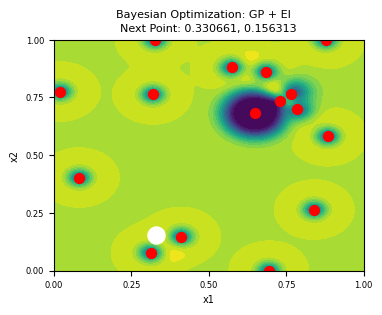

In [31]:
fig, ax = plt.subplots(1, 1,figsize=(4,3)) 

contour = ax.contourf(xx1, xx2, ei.reshape(500,500), levels=20, cmap='viridis')
ax.scatter(inputs[:,0], inputs[:,1], c='red', s=50, label='Observed')
ax.scatter(next_point[0], next_point[1], c='white', s=150, label='Next')

ax.set_title(f'Next Point: {next_point[0]:.6f}, {next_point[1]:.6f}', fontsize=8)
ax.set_xticks(np.linspace(0,1,5))
ax.set_yticks(np.linspace(0,1,5))
ax.set_xlabel("x1", fontsize=7)
ax.set_ylabel("x2", fontsize=7)
ax.tick_params(axis='both', labelsize=6)

fig.suptitle('Bayesian Optimization: GP + EI', fontsize=8)

plt.show()

<h1 style="color:#0000CD;font-size:19px;"">Week 8</h1>

**8.1 - Previous Week's Query Result**

In [32]:
# Queried Point result
x_new = np.array([0.330661, 0.156313])
y_new = 8.806551116051378e-56

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**8.2 - Next point query (EI)**

In [33]:
kernel = RBF(length_scale=0.2, length_scale_bounds=(0.05,1.0))+ WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
y_pred, sigma = gp.predict(X_grid, return_std=True)

# Best observed value so far
f_best = np.max(outputs)

# Expected Improvement
improvement = y_pred - f_best

# Z value
Z = improvement / sigma

# Expected Improvement
ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)

# Next point
index_max = np.argmax(ei)
next_point = X_grid[index_max]
print(f"Next point (with GP + EI): {next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP + EI): 0.639279-0.929860


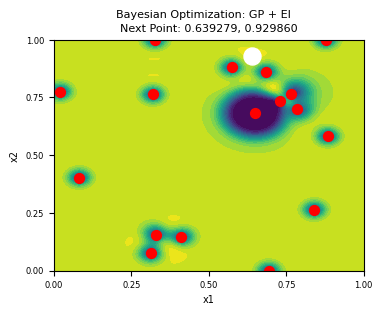

In [34]:
fig, ax = plt.subplots(1, 1,figsize=(4,3)) 

contour = ax.contourf(xx1, xx2, ei.reshape(500,500), levels=20, cmap='viridis')
ax.scatter(inputs[:,0], inputs[:,1], c='red', s=50, label='Observed')
ax.scatter(next_point[0], next_point[1], c='white', s=150, label='Next')

ax.set_title(f'Next Point: {next_point[0]:.6f}, {next_point[1]:.6f}', fontsize=8)
ax.set_xticks(np.linspace(0,1,5))
ax.set_yticks(np.linspace(0,1,5))
ax.set_xlabel("x1", fontsize=7)
ax.set_ylabel("x2", fontsize=7)
ax.tick_params(axis='both', labelsize=6)

fig.suptitle('Bayesian Optimization: GP + EI', fontsize=8)

plt.show()

<h1 style="color:#0000CD;font-size:19px;"">Week 9</h1>

**9.1 - Previous Week's Query Result**

In [35]:
# Queried Point result
x_new = np.array([0.639279, 0.929860])
y_new = 1.070313432884962e-63

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**9.2 - Observations after 8 weeks**

- All previous wide EI/UCB style points queried produced values close to zero or much worse than the current best [0.731024, 0.733000] → 7.710875e-16
- The only substantially adverse observation is [0.650114, 0.681526] → -0.003606063.
- The point [0.765531, 0.763527] already improved compared with most exploratory points, but it was still far worse than the current best.

**Conclusions**

The observations are consistent with a highly localised positive region around [0.731024, 0.733000],although the precise local geometry remains uncertain. Most observed outputs are concentrated close to zero, while the single substantially negative observation at [0.650114, 0.681526] dominates the overall output range. <br>

Given that 5  queries remain, the search will move from global exploration to local refinement (**local PI**). Probability of Improvement will be maximised within a small trust region around the current incumbent, using a shorter-length-scale and less smooth GP kernel. Because the surrogate remains fitted to all observations, the PI values are used primarily to rank candidate points within the local region rather than interpreted as precisely calibrated probabilities.

With that objective in mind, we will:

- restrict PI to a smaller region around the incumbent [0.731024, 0.733000]
- use a shorter-length-scale GP and a rougher kernel.


**9.3 - Next point query (Switch to Local PI)**

In [36]:
# Local PI configuration
x_best = inputs[np.argmax(outputs)]
y_best = np.max(outputs)

radius = 0.005          # tight trust region around current best
xi = 0.0                # no additional improvement margin
n_candidates = 50_000   # random local candidate search

# Short-lengthscale GP for narrow spike

kernel = ConstantKernel(1.0, (1e-6, 1e6)) * Matern(
    length_scale=np.array([0.0025, 0.0025]),
    length_scale_bounds=(1e-4, 0.05),
    nu=1.5
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-12,
    normalize_y=True,
    n_restarts_optimizer=20,
    random_state=42
)

gp.fit(inputs, outputs)

# Random candidates inside Trust region

rng = np.random.default_rng(42)
lower = np.maximum(0.0, x_best - radius)
upper = np.minimum(1.0, x_best + radius)
X_cand = rng.uniform(lower, upper, size=(n_candidates, inputs.shape[1]))

# Probability of Improvement

mu, sigma = gp.predict(X_cand, return_std=True)
sigma = np.maximum(sigma, 1e-12)

z = (mu - y_best - xi) / sigma
PI = norm.cdf(z)

# Next point
index_max = np.argmax(PI)
next_point = X_cand[index_max]
print(f"Next point (with GP + PI): {next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP + PI): 0.731124-0.733063


**9.4 - Visualising the Transition from Global EI to Local PI**

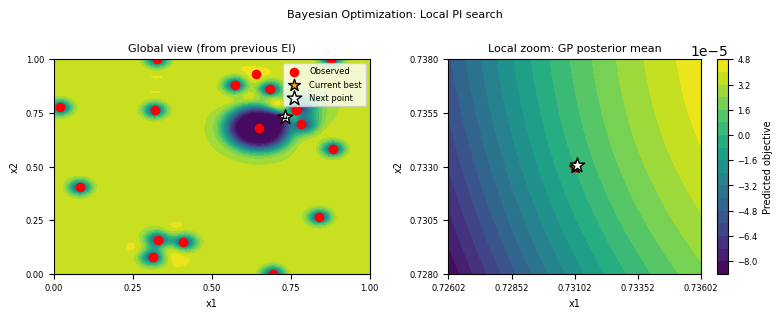

In [37]:
# ----- local Grid for the Zoomed contour -----
grid_size = 300
x1_local = np.linspace(lower[0], upper[0], grid_size)
x2_local = np.linspace(lower[1], upper[1], grid_size)
xx1_local, xx2_local = np.meshgrid(x1_local, x2_local)
X_local_grid = np.column_stack([xx1_local.ravel(),xx2_local.ravel()])

mu_local, sigma_local = gp.predict(X_local_grid, return_std=True)
mu_surface = mu_local.reshape(xx1_local.shape)

# observations inside trust region
local_mask = np.all((inputs >= lower) & (inputs <= upper), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))

# LEFT PANEL: Global Overview

ax = axes[0]

contour = ax.contourf(xx1, xx2, ei.reshape(500,500), levels=20, cmap='viridis')
ax.scatter(inputs[:, 0], inputs[:, 1], c='red', s=35, label='Observed')
ax.scatter(x_best[0], x_best[1], c='orange', edgecolors='black', s=80, marker='*', label='Current best')
ax.scatter(next_point[0], next_point[1], c='white', edgecolors='black', s=120, marker='*', label='Next point')

# trust-region box
rect = Rectangle((lower[0], lower[1]), upper[0] - lower[0], upper[1] - lower[1], fill=False, edgecolor='black', linestyle='--',linewidth=1.0)
ax.add_patch(rect)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks(np.linspace(0, 1, 5))
ax.set_yticks(np.linspace(0, 1, 5))
ax.set_xlabel("x1", fontsize=7)
ax.set_ylabel("x2", fontsize=7)
ax.tick_params(axis='both', labelsize=6)
ax.set_title("Global view (from previous EI)", fontsize=8)
ax.legend(fontsize=6, loc='best')

# RIGHT PANEL: local Zoom

ax = axes[1]

contour = ax.contourf(xx1_local, xx2_local, mu_surface, levels=20,cmap='viridis')

ax.scatter(inputs[local_mask, 0], inputs[local_mask, 1], c='red', s=40, label='Observed', zorder=3)
ax.scatter(x_best[0], x_best[1], c='orange', edgecolors='black', s=80, marker='*', label='Current best', zorder=4)
ax.scatter(next_point[0],next_point[1],c='white',edgecolors='black',s=120,marker='*',label='Next point', zorder=5)

ax.set_xlim(lower[0], upper[0])
ax.set_ylim(lower[1], upper[1])
ax.set_xticks(np.linspace(lower[0], upper[0], 5))
ax.set_yticks(np.linspace(lower[1], upper[1], 5))
ax.set_xlabel("x1", fontsize=7)
ax.set_ylabel("x2", fontsize=7)
ax.tick_params(axis='both', labelsize=6)
ax.set_title("Local zoom: GP posterior mean", fontsize=8)

cbar = fig.colorbar(contour, ax=ax)
cbar.ax.tick_params(labelsize=6)
cbar.set_label("Predicted objective", fontsize=7)

fig.suptitle("Bayesian Optimization: Local PI search", fontsize=8)
fig.tight_layout()
plt.show()

<h1 style="color:#0000CD;font-size:19px;"">Week 10</h1>

**10.1 - Previous Week's Query Result**

In [38]:
# Queried Point result
x_new = np.array([0.731124, 0.733063])
y_new = 7.232455306377106e-16

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**10.2 - Next point query (Local PI)**
    
- The first Local PI query produced the strongest sequentially queried result so far, although it remained below the initial incumbent. The trust-region radius is increased from 0.005 to 0.01 to test whether improvement may lie slightly farther from the incumbent.

In [39]:
# Local PI configuration

x_best = inputs[np.argmax(outputs)]
y_best = np.max(outputs)
print(x_best, y_best)
radius = 0.01         # tight trust region around current best
xi = 0.0                # no additional improvement margin
n_candidates = 50_000   # random local candidate search

# Short-lengthscale GP for narrow spike

kernel = ConstantKernel(1.0, (1e-6, 1e6)) * Matern(
    length_scale=np.array([0.0025, 0.0025]),
    length_scale_bounds=(1e-4, 0.05),
    nu=1.5
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-12,
    normalize_y=True,
    n_restarts_optimizer=20,
    random_state=42
)

gp.fit(inputs, outputs)

# Random candidates inside Trust region

rng = np.random.default_rng(42)
lower = np.maximum(0.0, x_best - radius)
upper = np.minimum(1.0, x_best + radius)
X_cand = rng.uniform(lower, upper, size=(n_candidates, inputs.shape[1]))

# Probability of Improvement

mu, sigma = gp.predict(X_cand, return_std=True)
sigma = np.maximum(sigma, 1e-12)

z = (mu - y_best - xi) / sigma
PI = norm.cdf(z)

# Next point
index_max = np.argmax(PI)
next_point = X_cand[index_max]
print(f"Next point (with GP + PI): {next_point[0]:.6f}-{next_point[1]:.6f}")

[0.73102363 0.73299988] 7.710875114502849e-16
Next point (with GP + PI): 0.740979-0.733546


<h1 style="color:#0000CD;font-size:19px;"">Week 11</h1>

**11.1 - Previous Week's Query Result**

In [40]:
# Queried Point result
x_new = np.array([0.740979, 0.733546])
y_new = 7.467654736306343e-18

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**11.2 - Next point query (Local PI)**
    
- The larger-radius query returned a substantially weaker value. The trust-region radius is therefore contracted to 0.001 around the incumbent.

In [41]:
# Local PI configuration

x_best = inputs[np.argmax(outputs)]
y_best = np.max(outputs)

radius = 0.001         # tight trust region around current best
xi = 0.0                # no additional improvement margin
n_candidates = 50_000   # random local candidate search

# Short-lengthscale GP for narrow spike

kernel = ConstantKernel(1.0, (1e-6, 1e6)) * Matern(
    length_scale=np.array([0.0025, 0.0025]),
    length_scale_bounds=(1e-4, 0.05),
    nu=1.5
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-12,
    normalize_y=True,
    n_restarts_optimizer=20,
    random_state=42
)

gp.fit(inputs, outputs)

# Random candidates inside Trust region

rng = np.random.default_rng(42)
lower = np.maximum(0.0, x_best - radius)
upper = np.minimum(1.0, x_best + radius)
X_cand = rng.uniform(lower, upper, size=(n_candidates, inputs.shape[1]))

# Probability of Improvement

mu, sigma = gp.predict(X_cand, return_std=True)
sigma = np.maximum(sigma, 1e-12)

z = (mu - y_best - xi) / sigma
PI = norm.cdf(z)

# Next point
index_max = np.argmax(PI)
next_point = X_cand[index_max]
print(f"Next point (with GP + PI): {next_point[0]:.6f}-{next_point[1]:.6f}")

Next point (with GP + PI): 0.731051-0.733016


<h1 style="color:#0000CD;font-size:19px;"">Week 12</h1>

**12.1 - Previous Week's Query Result**

In [42]:
# Queried Point result
x_new = np.array([0.731051, 0.733016])
y_new = 7.515668783384148e-16

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**12.2 - Local Exploitation Refinement**

The Local PI queries have identified nearby high-value points but have not improved the incumbent. With two evaluations remaining, the search switches from model-based PI to deterministic directional probes around the incumbent. The next probe is [0.731010,0.732975].


<h1 style="color:#0000CD;font-size:19px;"">Week 13</h1>

**13.1 - Previous Week's Query Result**

In [43]:
# Queried Point result
x_new = np.array([0.731010, 0.732975])
y_new = 7.829289359620921e-16

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


**13.2 - Local Exploitation Refinement**

The latest point is [0.731010, 0.732975] → 7.829289e-16, is slightly better than the original [0.731024, 0.733000] → 7.710875e-16 and better than the nearby north east probes. The nearby probes suggest slightly higher observed values toward the south-west, although the differences are small. A second south-west probe, [0.730950,0.732920], is submitted to test whether this directional improvement persists.

<h1 style="color:#0000CD;font-size:19px;"">Final Results</h1>

In [44]:
# Queried Point result
x_new = np.array([0.730950, 0.732920])
y_new = 8.190853877855047e-16

data = add_QueriedPoint(data, x_new, y_new)
inputs = data[['x1', 'x2']].to_numpy()
outputs = data['y'].to_numpy()
display(data)

Point added!


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


The experiment began with 10 initial observations and added 13 sequentially selected queries:

- Initial best: [0.731024,0.733000] with y=7.710875×10−16
- Final best: [0.730950,0.732920] with y=8.190854×10−16
- Absolute improvement: 4.799788×10−17
- Relative improvement over the initial incumbent: ~6.22%

The global UCB and EI phases improved domain coverage but did not outperform the initial incumbent. The improvement was obtained during the final local directional-refinement phase. Given the sparse evaluation budget and the exceptionally small objective scale near the incumbent, the final point should be interpreted as the best observed configuration, not as proof of the global maximum.